# **Load data + datetime features**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Week 2 (DataSet).xlsx", sheet_name="Steel_industry_data")

print(df.shape)
print(df.info())
print(df.head())
print(df.isnull().sum())

df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day_of_week_derived'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)

(35040, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: 

# **Power_Factor_Ratio**

In [6]:
df['Power_Factor_Ratio'] = np.where(
    (df['Leading_Current_Power_Factor'] == 0) & (df['Lagging_Current_Power_Factor'] == 0),
    1.0,
    df['Leading_Current_Power_Factor'] / df['Lagging_Current_Power_Factor']
)

# **High_Load binary feature**

In [7]:
threshold = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = (df['Usage_kWh'] > threshold).astype(int)

# **Outlier detection (IQR) + boxplot**

Number of outliers in Usage_kWh: 328


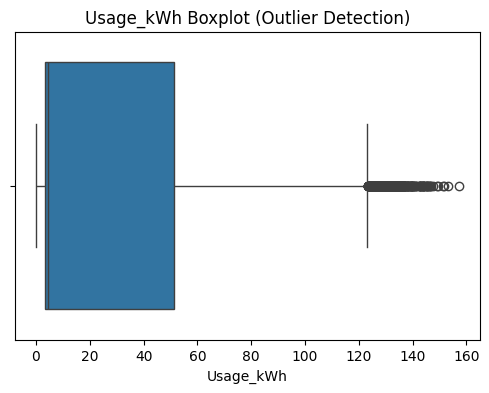

In [8]:
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Usage_kWh'] < lower) | (df['Usage_kWh'] > upper)]
print(f"Number of outliers in Usage_kWh: {len(outliers)}")

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Usage_kWh'])
plt.title("Usage_kWh Boxplot (Outlier Detection)")
plt.show()

# **Correlation heatmap — top 3 features**

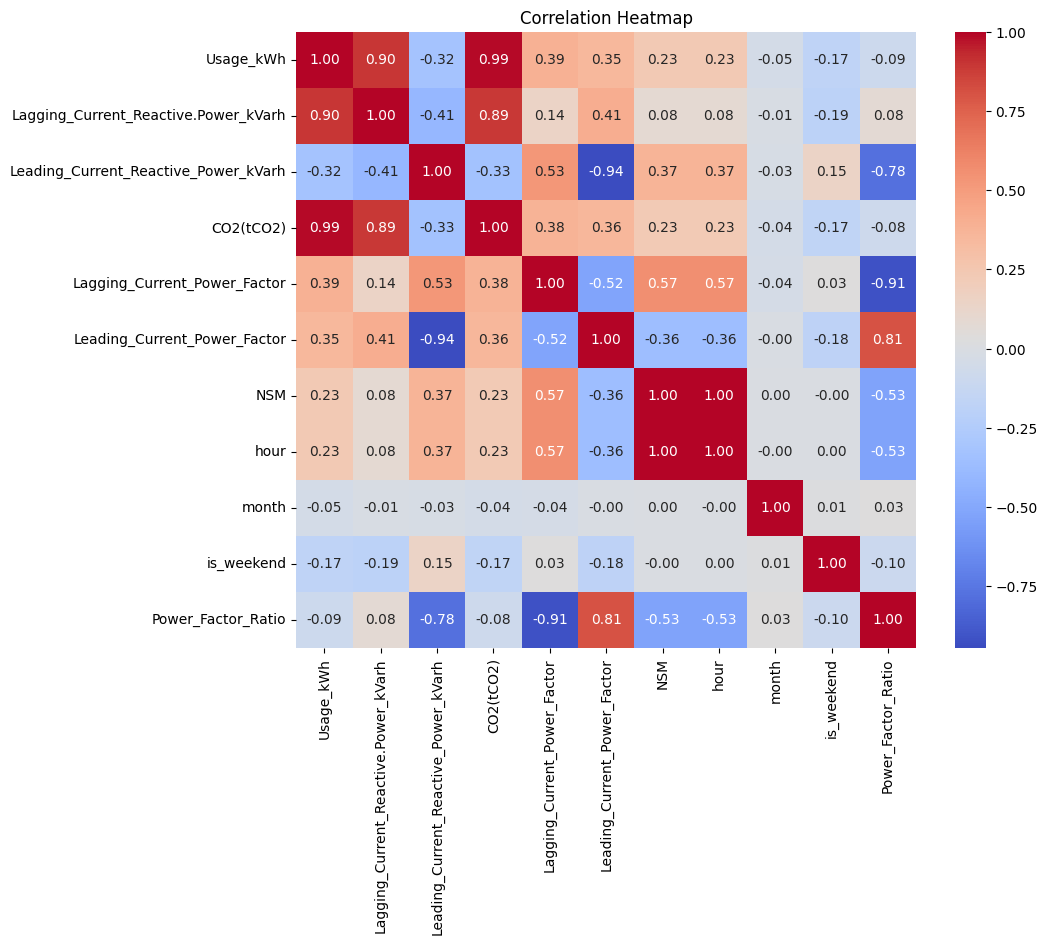

Top 3 features correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
Lagging_Current_Power_Factor            0.38596
Name: Usage_kWh, dtype: float64


In [9]:
leak_cols = ['High_Load']  # anything derived directly from Usage_kWh
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=leak_cols)

corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

top3 = corr['Usage_kWh'].drop('Usage_kWh').abs().sort_values(ascending=False).head(3)
print("Top 3 features correlated with Usage_kWh:")
print(top3)

# **Grouped bar chart — avg consumption by Load_Type**

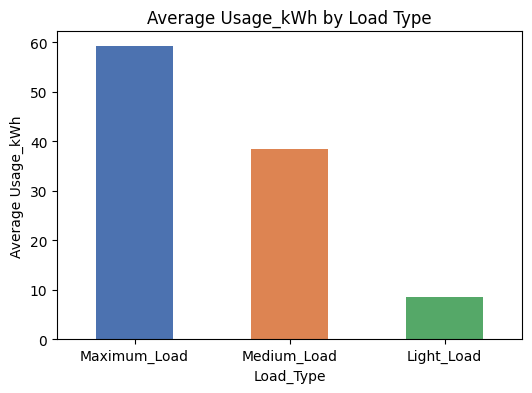

In [10]:
load_avg = df.groupby('Load_Type')['Usage_kWh'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
load_avg.plot(kind='bar', color=['#4C72B0', '#DD8452', '#55A868'])
plt.title("Average Usage_kWh by Load Type")
plt.ylabel("Average Usage_kWh")
plt.xticks(rotation=0)
plt.show()

# **Line chart — avg usage by hour**

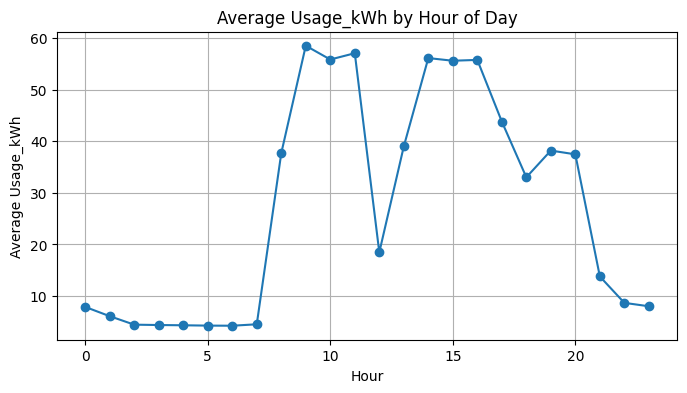

In [11]:
hourly_avg = df.groupby('hour')['Usage_kWh'].mean()

plt.figure(figsize=(8, 4))
hourly_avg.plot(kind='line', marker='o')
plt.title("Average Usage_kWh by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Usage_kWh")
plt.grid(True)
plt.show()

## EDA Summary

The dataset has 35,040 rows and no missing values, so no cleaning was needed there. The main issue I found isn't missing data, it's repeated information. `NSM` and `hour` are basically the same thing (correlation of 1.00) since NSM is just seconds since midnight. Same with `CO2(tCO2)` and `Usage_kWh` , they're correlated at 0.99, but that's because CO2 in this dataset is calculated directly from energy usage, not measured separately. So it looks like a strong predictor but it's really just the same number in a different form. The features that actually tell you something new are `Lagging_Current_Reactive.Power_kVarh` (0.90) and `Lagging_Current_Power_Factor` (0.39) , these come from real electrical readings, not from the target itself.

Using the IQR method, I found 328 outliers in `Usage_kWh`. This matches what the boxplot shows , the data is skewed toward lower usage with a long tail of high readings. These aren't errors, they're just periods of heavy machine use.

The most interesting pattern is in the hourly chart. Usage stays low overnight (5-8 kWh), then jumps fast between 6-9am to around 55-60 kWh, dips at midday to about 18 kWh, picks back up in the afternoon, and drops off after 8pm. This looks like a two-shift work schedule with a break or shift change around noon.

My guess is that the energy spikes come from machines starting up together at the beginning of a shift, not from usage slowly building up. The jump in the morning is too sudden for it to be gradual demand , it looks more like everything turning on at once.
